In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data_path = '../data/02_intermediate/preprocessed_creep_data.pq'
df = pd.read_parquet(data_path)
df

,Material,Family,Material_info,Dry_or_cond,Manufacturer,Polymer,Fiber_percentage,Fiber_type,Charpy_notched_+23C,Charpy_notched_-30C,...,CM_10,CM_100,CM_1000,CM_10000,CM_100000,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000
0,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,769.231,645.161,540.541,434.783,NaN,0.884616,0.838709,0.837839,0.804348,NaN
1,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,701.754,597.015,512.820,430.108,NaN,0.894736,0.850747,0.858973,0.838711,NaN
2,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,618.557,535.714,461.538,392.157,NaN,0.876290,0.866071,0.861538,0.849674,NaN
3,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,571.429,484.848,418.848,353.982,NaN,0.871429,0.848483,0.863875,0.845132,NaN
4,Akulon® F-X9190,Akulon®,F-X9190,cond,DSM Engineering Materials,PA6,0.00,None,NaN,35.0,...,511.524,429.765,369.232,312.232,NaN,0.847924,0.840166,0.859149,0.845626,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6356,Zytel® XT70G35HSL BK044A,Zytel®,XT70G35HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.35,GF,13.0,NaN,...,1973.680,1734.100,1470.590,NaN,NaN,0.868418,0.878613,0.848042,NaN,NaN
6357,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,6512.300,6480.650,6101.690,NaN,NaN,0.990262,0.995140,0.941524,NaN,NaN
6358,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,5836.580,5769.230,5454.550,NaN,NaN,0.992219,0.988461,0.945455,NaN,NaN
6359,Zytel® XT70G50HSL BK044A,Zytel®,XT70G50HSL BK044A,dry,DuPont Engineering Polymers,PA66,0.50,GF,15.0,13.0,...,5154.640,5060.890,4804.800,NaN,NaN,0.994791,0.981813,0.949398,NaN,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 37 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Material                               6361 non-null   object 
 1   Family                                 6361 non-null   object 
 2   Material_info                          6361 non-null   object 
 3   Dry_or_cond                            6361 non-null   object 
 4   Manufacturer                           6361 non-null   object 
 5   Polymer                                6361 non-null   object 
 6   Fiber_percentage                       6361 non-null   float64
 7   Fiber_type                             6361 non-null   object 
 8   Charpy_notched_+23C                    4196 non-null   float64
 9   Charpy_notched_-30C                    4079 non-null   float64
 10  Charpy_+23C                            4152 non-null   float64
 11  Tens

In [14]:
df.describe()

,Fiber_percentage,Charpy_notched_+23C,Charpy_notched_-30C,Charpy_+23C,Tensile_modulus,Molding_shrinkage_normal,Molding_shrinkage_parallel,Coeff_linear_therm_expansion_normal,Coeff_linear_therm_expansion_parallel,Melting_temp,...,CM_10,CM_100,CM_1000,CM_10000,CM_100000,R_10/1,R_100/10,R_1000/100,R_10000/1000,R_100000/10000
count,6361.000000,4196.000000,4079.000000,4152.000000,6225.000000,5089.000000,5089.000000,4730.000000,5963.000000,4559.000000,...,6354.000000,6357.000000,6327.000000,4705.000000,2352.000000,4669.000000,6350.000000,6327.000000,4705.000000,2352.000000
mean,0.174881,21.975906,14.505271,72.922086,6417.309237,0.976773,0.662822,89.931501,57.984018,233.629085,...,3049.350021,2775.954180,2476.538926,1843.517995,1537.210701,0.901482,0.887109,0.869638,0.846278,0.826634
std,0.185847,25.180744,21.220688,60.941494,5035.841801,0.378416,0.493517,34.065030,43.165808,35.884871,...,3093.857653,2885.287474,2616.534016,2117.047809,1460.180376,0.058745,0.074643,0.088913,0.103952,0.131294
min,0.000000,2.000000,2.000000,1.500000,12.000000,0.300000,0.100000,24.000000,4.000000,134.000000,...,8.649330,8.161390,7.725250,7.281490,6.097560,0.598983,0.413901,0.360545,0.348859,0.324044
25%,0.000000,7.000000,6.500000,35.000000,2400.000000,0.700000,0.300000,65.000000,22.000000,220.000000,...,1083.590000,865.216000,677.584000,471.698000,471.715250,0.876290,0.866401,0.843090,0.813042,0.817746
50%,0.150000,12.000000,10.000000,65.000000,4500.000000,0.900000,0.500000,85.000000,50.000000,223.000000,...,2043.020000,1873.580000,1679.560000,1150.570000,1109.265000,0.915640,0.907551,0.895161,0.875283,0.871192
75%,0.300000,18.000000,14.000000,90.000000,9800.000000,1.100000,0.700000,105.000000,85.000000,260.000000,...,4050.540000,3727.250000,3404.000000,2504.070000,2126.467500,0.941544,0.936364,0.928521,0.915563,0.914667
max,0.650000,120.000000,160.000000,300.000000,22500.000000,2.100000,2.400000,230.000000,230.000000,340.000000,...,24861.300000,24468.600000,23190.700000,20970.200000,12576.400000,0.999463,0.999415,0.999612,0.996404,0.987717


## Counting

In [15]:
len(df.Material.unique())

415

In [16]:
len(df.Family.unique())

44

In [19]:
df.Family.value_counts()

Ultramid®       1213
Makrolon®        950
Ultradur®        583
Zytel®           468
Luran®           304
Durethan         296
Ultraform®       249
Crastin®         203
Grivory          189
Hytrel®          187
Akulon®          165
Grilon           159
Pocan            144
Stanyl®          137
Apec®             93
Ultrason®         91
VESTAMID®         75
PLEXIGLAS®        71
CELANEX®          66
HOSTAFORM®        64
Rilsan®           63
Pebax®            62
FORTRON®          53
Elastollan®       52
Grilamid          43
Minlon®           40
Novodur®          36
Styrolution®      33
Styrolux®         27
Terluran®         23
Terblend®         23
Rilsamid®         23
Arnite®           22
Bayblend®         21
IMPET®            20
Terlux®           19
VESTODUR®         18
Orgalloy®         18
Delrin®           16
CELCON®           14
Rynite®           12
TROGAMID®          9
CELSTRAN®          4
VESTAKEEP®         3
Name: Family, dtype: int64

In [17]:
len(df.Polymer.unique())

49

In [27]:
df.Polymer.value_counts()

PA66                               1138
PC                                 1043
PA6                                 924
PBT                                 810
POM                                 292
TPC                                 187
ASA                                 166
PA46                                137
PA666                               113
PA12                                101
SAN                                  97
PBT+ASA+PET                          87
PA66+PA6I/X                          83
PA6T/6                               78
TPA                                  73
PMMA                                 71
PA6T/6I                              70
PBT+PET                              65
PA11                                 63
PESU                                 60
ABS                                  59
PPS                                  53
TPU                                  52
POM+PUR                              51
PET                                  47


In [21]:
len(df.Fiber_type.unique())

10

In [22]:
df.Fiber_type.value_counts()

None     2983
GF       2979
M          97
GF+M       94
GB         87
GF+GB      39
GF+MF      37
CF         24
GLF        16
P+GF        5
Name: Fiber_type, dtype: int64

In [23]:
len(df.Temperature.unique())

14

In [24]:
df.Temperature.value_counts()

23.0     2345
60.0      780
120.0     730
90.0      674
40.0      638
80.0      364
140.0     212
160.0     189
100.0     182
150.0      98
180.0      65
200.0      38
110.0      26
130.0      20
Name: Temperature, dtype: int64

In [25]:
len(df.Load.unique())

82

In [28]:
df.Load.value_counts()

10.0    900
20.0    771
30.0    530
5.0     513
15.0    490
       ... 
49.0      1
54.0      1
87.0      1
59.0      1
29.0      1
Name: Load, Length: 82, dtype: int64

## Histograms:

In [47]:
def plot_histograms(df_list, label_list=None, n_bins=10, n_cols=6):
    '''Make subplots for histograms of each feature in each df in df_list. Maximum 6 subplots per row.
    Each df in df_list will have its own color'''

    df_ = pd.DataFrame(df_list[0]) # Get first df in df_list for formatting. Supposing all dfs in df_list have the same columns. 
    # Converted to DataFrame to allow for column names in case it is a series

    n_rows = int(np.ceil(len(df_.columns) / 6))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4), tight_layout=True)

    #Make color list for each df in df_list from 'tab10' color palette
    colors = sns.color_palette('tab10', len(df_list))

    for j, df in enumerate(df_list):
        if isinstance(df, pd.Series): #If df is a series, convert to dataframe
            df = df.to_frame()
        for i, col in enumerate(df.columns):
            ax = axes.flatten()[i]
            ax.hist(df[col], bins=n_bins, color=colors[j], alpha=0.5)
            ax.set_title(col)
        if label_list:
            #locate legend outside of subplots, in the top center, with bigger font
            fig.legend(label_list, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(df_list), fontsize='x-large')

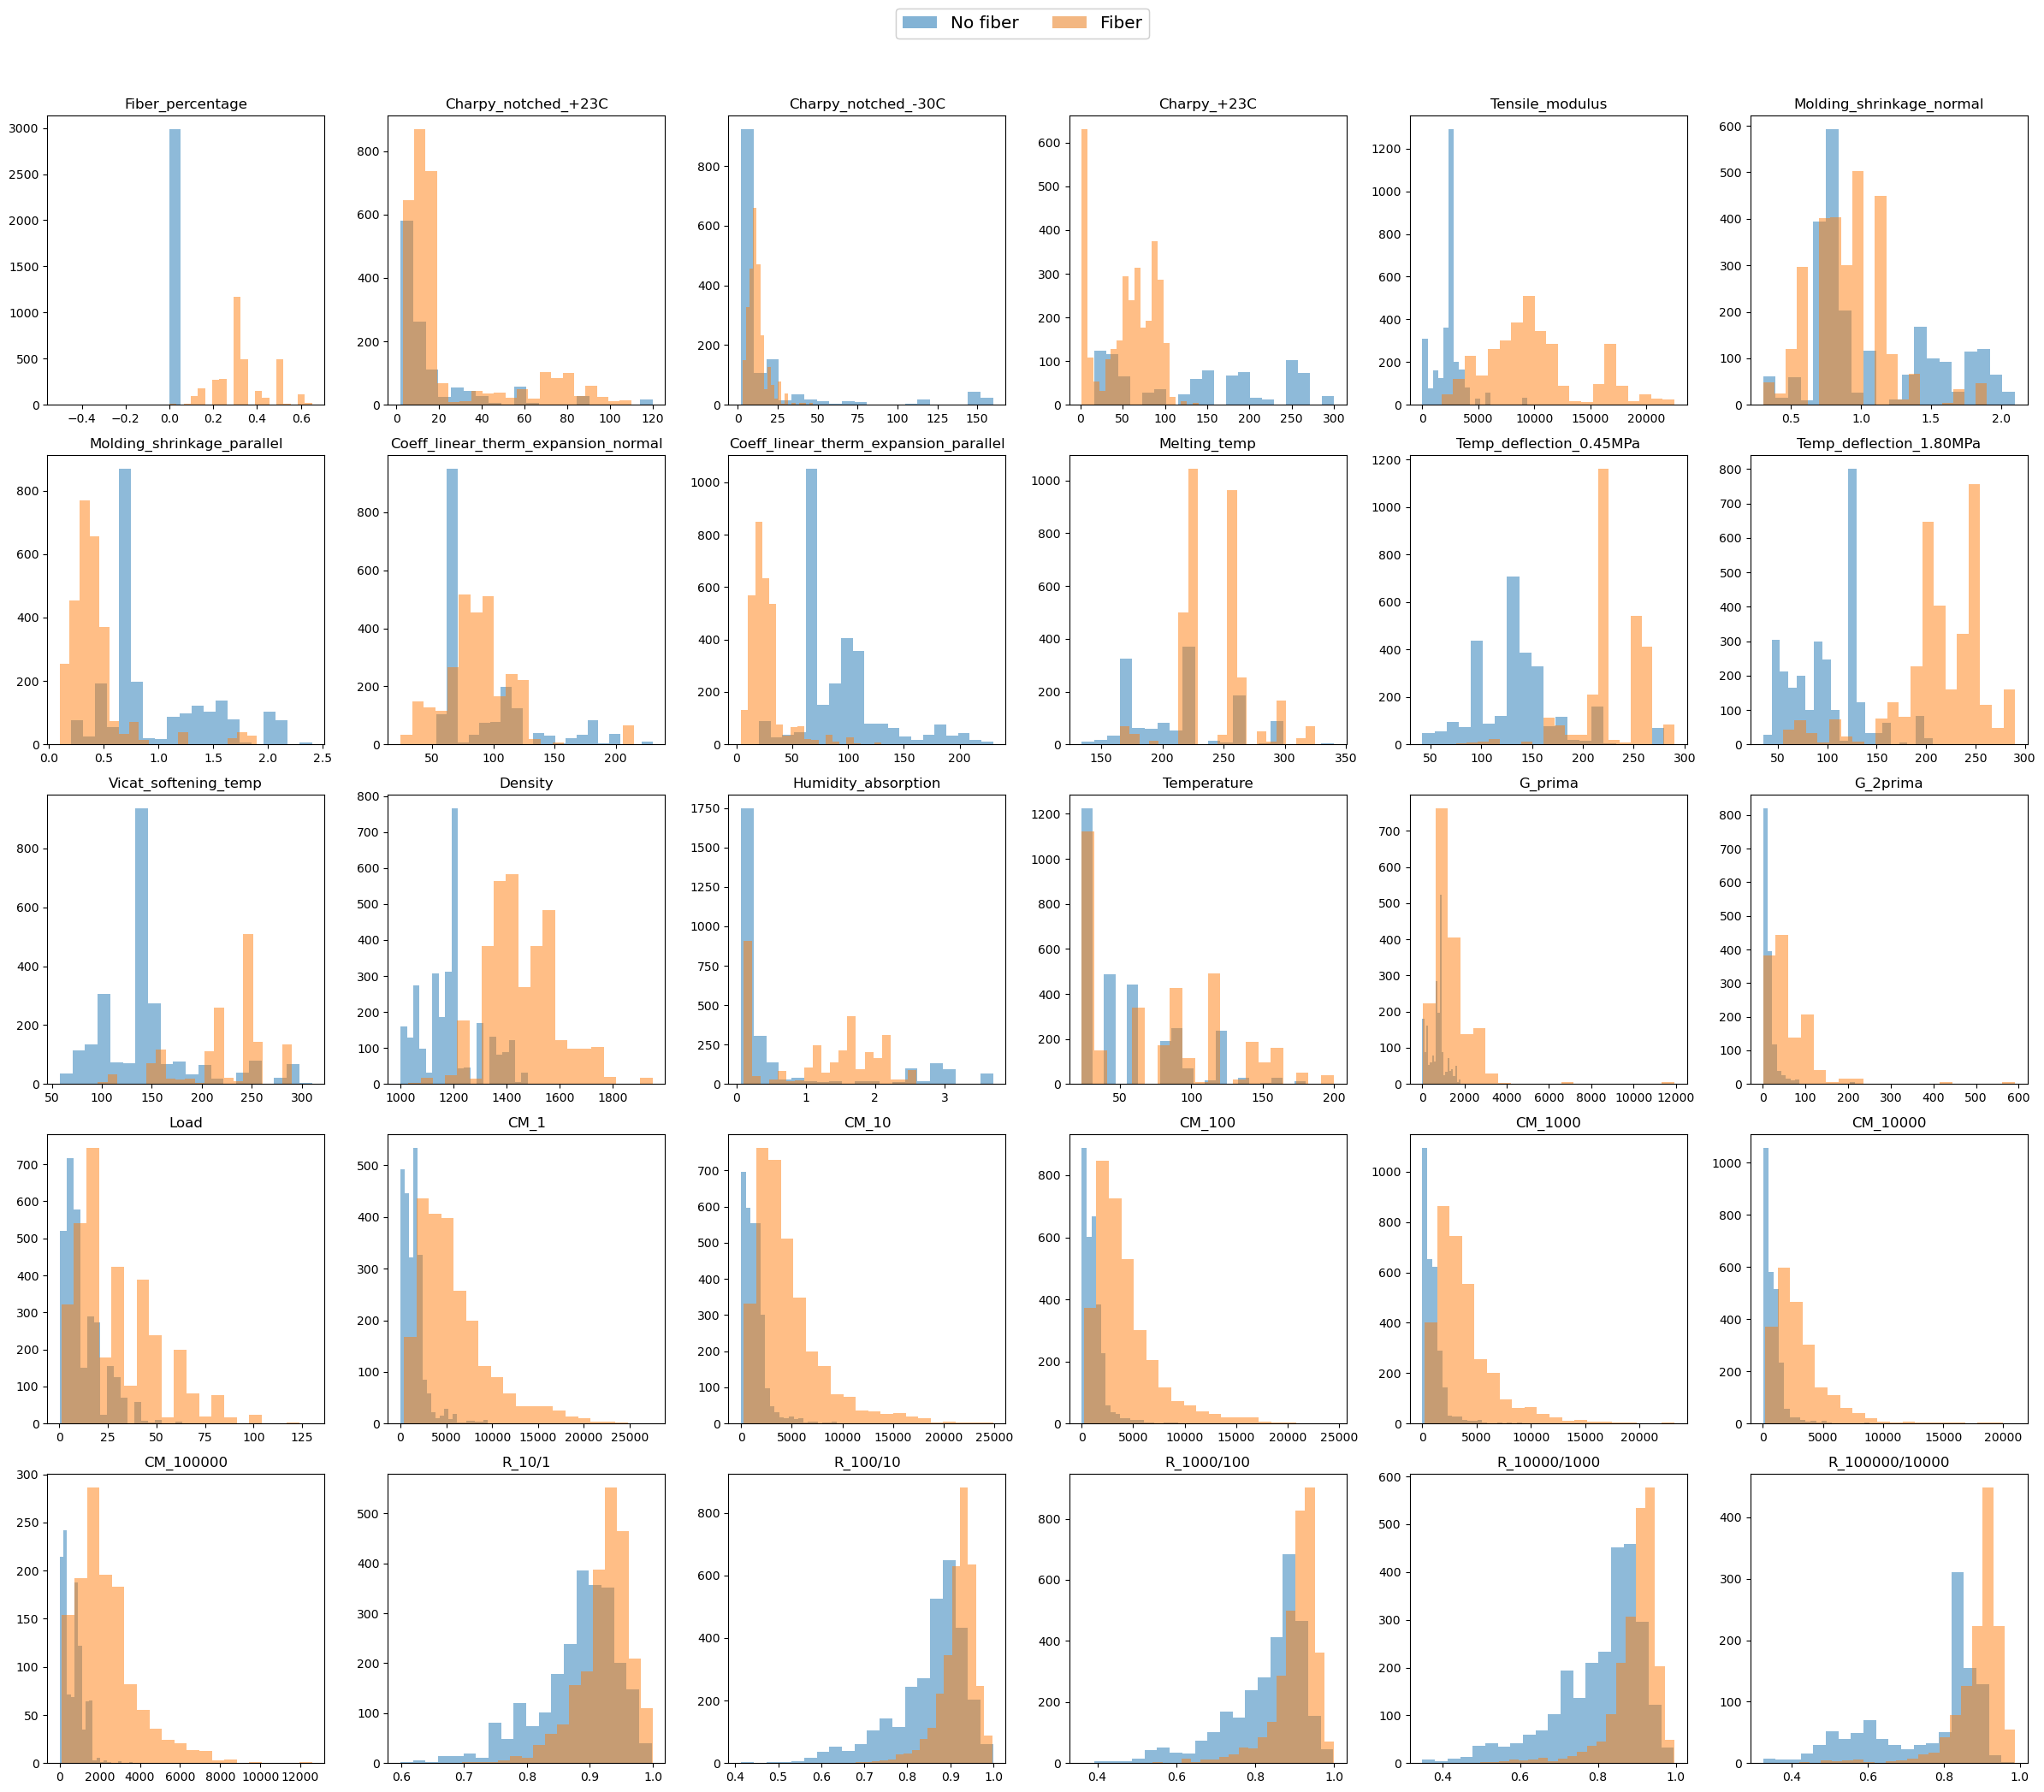

In [48]:
df_no_fiber = df[df['Fiber_type'] == 'None'].select_dtypes(include=np.number)
df_fiber = df[df['Fiber_type'] != 'None'].select_dtypes(include=np.number)

plot_histograms([df_no_fiber, df_fiber], label_list=['No fiber', 'Fiber'], n_bins=20)